<a href="https://colab.research.google.com/github/overwatch093-alt/Applied-Data-Science-1/blob/main/ADS1_Tutorial_2_2_Categorical_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Let's start by randomly generated 4 sets of sample data sets
# Explore what is np.random.normal ( )?
sample1 = np.random.normal(-1.0, 1.0, 10000)
sample2 = np.random.normal(1.0, 0.5, 10000)
sample3 = np.random.normal(0.0, 1.5, 10000)
sample4 = np.random.normal(-0.2, 2.0, 10000)
# Test by printing out each sample data sets, Example print(sample1)
# Find out the data type of the samples

In [3]:
def plot_subplotted_histograms(sample1, sample2, sample3, sample4):
    """
    The following scripts will Plots 4 histograms as subplots. Understand what is subplots?
    """
    fig, axs = plt.subplots(2, 2, dpi=144)
    axs = axs.flatten()

    axs[0].hist(sample1)
    axs[1].hist(sample2)
    axs[2].hist(sample3)
    axs[3].hist(sample4)

    for i, ax in enumerate(axs):
        ax.set_ylabel('N')
        ax.set_title('Sample ' + str(i + 1))

    fig.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.show()
    return

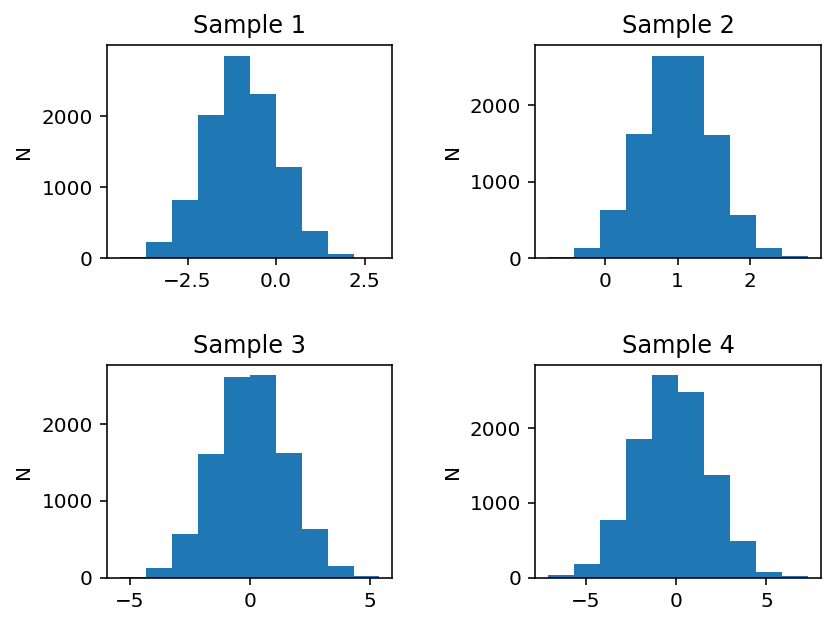

In [4]:
plot_subplotted_histograms(sample1, sample2, sample3, sample4)

In [6]:
def plot_overplotted_histograms(*samples):
    """
    Plots 4 histograms on top of each other
    """
    plt.figure(dpi=144)

    for i, sample in enumerate(samples):
        plt.hist(sample, label='Sample ' + str(i + 1), range=(-5, 5), bins=10, alpha=0.5)

    plt.ylabel('N')
    plt.xlim(-5, 5)
    plt.legend()
    plt.show()
    return

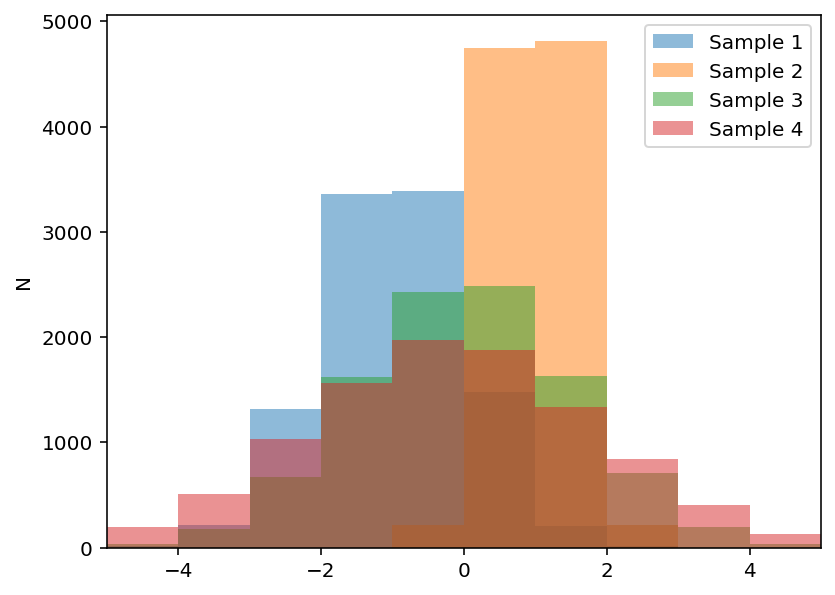

In [7]:
plot_overplotted_histograms(sample1, sample2, sample3, sample4)

          price  ann_return
year                       
1989  24.494144   22.941372
1990  30.810261   17.814613
1991  36.818260    5.895034
1992  39.053959    5.149691
1993  41.117802  -12.174125
          price  ann_return
year                       
1989  41.180229   19.174906
1990  49.884350  -11.157063
1991  44.617970   -6.082900
1992  41.984802  -15.618524
1993  35.913830   46.029975
         price  ann_return
year                      
1987  1.515162    4.754541
1988  1.587201   -0.986012
1989  1.571551   25.596115
1990  1.973807   12.323343
1991  2.217046   -0.793578
         price  ann_return
year                      
1989  4.003933   33.478386
1990  5.596050  -21.962895
1991  4.492602   17.645562
1992  5.359591   10.330250
1993  5.942858   48.265578


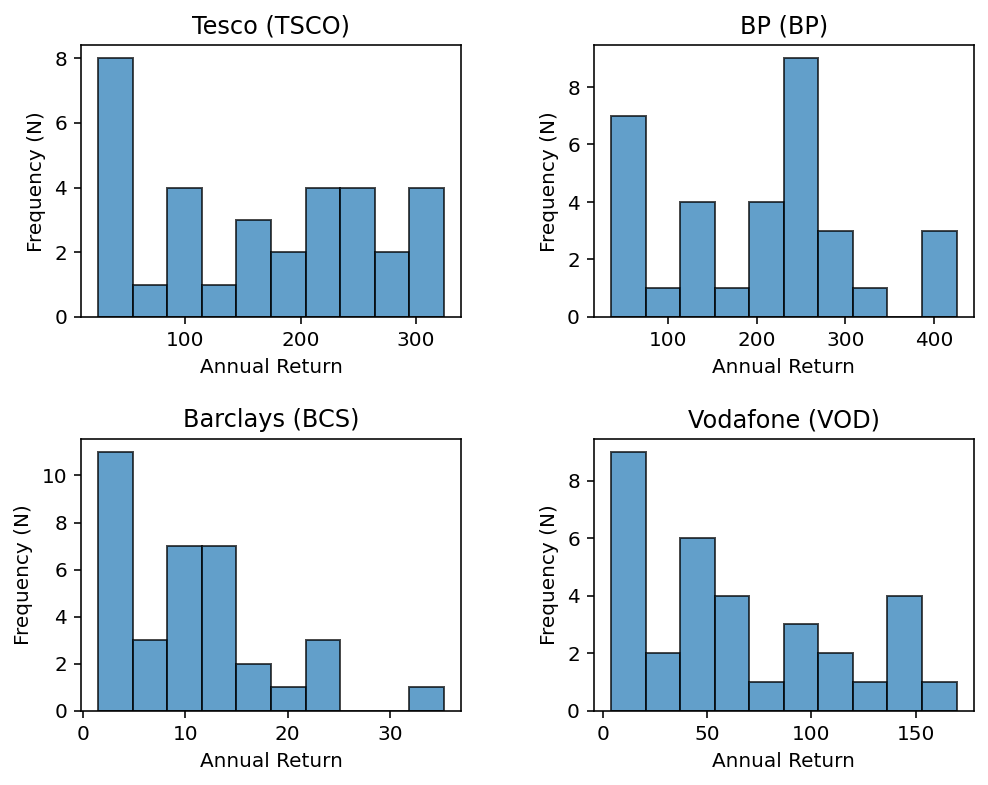

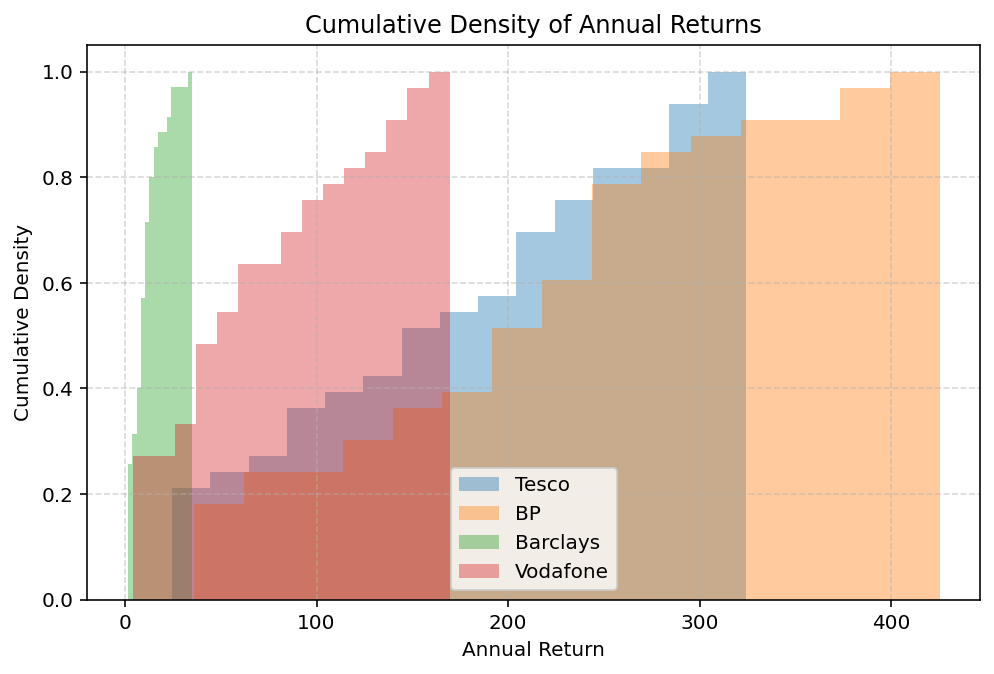

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the 4 datasets (assumes filenames follow .csv extensions on Blackboard)
df_tesco = pd.read_csv('TSCO_ann.csv', index_col='year')
df_bp = pd.read_csv('BP_ann.csv', index_col='year')
df_barclays = pd.read_csv('BCS_ann.csv', index_col='year')
df_vodaphone = pd.read_csv('VOD_ann.csv', index_col='year')

print(df_tesco.head())
print(df_bp.head())
print(df_barclays.head())
print(df_vodaphone.head())

# Extract the return series (usually the first data column after 'year')
ret_tesco = df_tesco.iloc[:, 0].dropna()
ret_bp = df_bp.iloc[:, 0].dropna()
ret_barclays = df_barclays.iloc[:, 0].dropna()
ret_vodaphone = df_vodaphone.iloc[:, 0].dropna()


def plot_subplotted_annual_returns(s1, s2, s3, s4):
  """Plots 4 histograms of annual returns as 2x2 subplots."""
  fig, axs = plt.subplots(2, 2, dpi=144, figsize=(8, 6))
  axs = axs.flatten()

  datasets = [s1, s2, s3, s4]
  titles = ['Tesco (TSCO)', 'BP (BP)', 'Barclays (BCS)', 'Vodafone (VOD)']

  for i, ax in enumerate(axs):
    ax.hist(datasets[i], bins=10, edgecolor='black', alpha=0.7)
    ax.set_title(titles[i])
    ax.set_xlabel('Annual Return')
    ax.set_ylabel('Frequency (N)')

  fig.subplots_adjust(wspace=0.35, hspace=0.45)
  plt.show()


plot_subplotted_annual_returns(
    ret_tesco, ret_bp, ret_barclays, ret_vodaphone
)


def plot_overplotted_annual_returns(s1, s2, s3, s4):
  """Plots 4 histograms on top of each other as a cumulative density distribution."""
  plt.figure(dpi=144, figsize=(8, 5))

  datasets = [s1, s2, s3, s4]
  labels = ['Tesco', 'BP', 'Barclays', 'Vodafone']

  for data, label in zip(datasets, labels):
    plt.hist(
        data,
        label=label,
        bins=15,
        alpha=0.4,
        density=True,
        cumulative=True,
        histtype='stepfilled',
    )

  plt.title('Cumulative Density of Annual Returns')
  plt.xlabel('Annual Return')
  plt.ylabel('Cumulative Density')
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()


plot_overplotted_annual_returns(
    ret_tesco, ret_bp, ret_barclays, ret_vodaphone
)

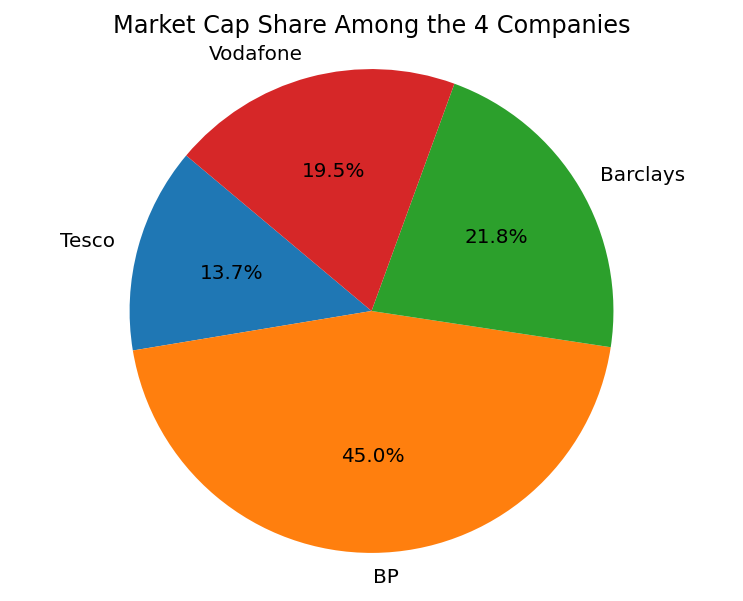

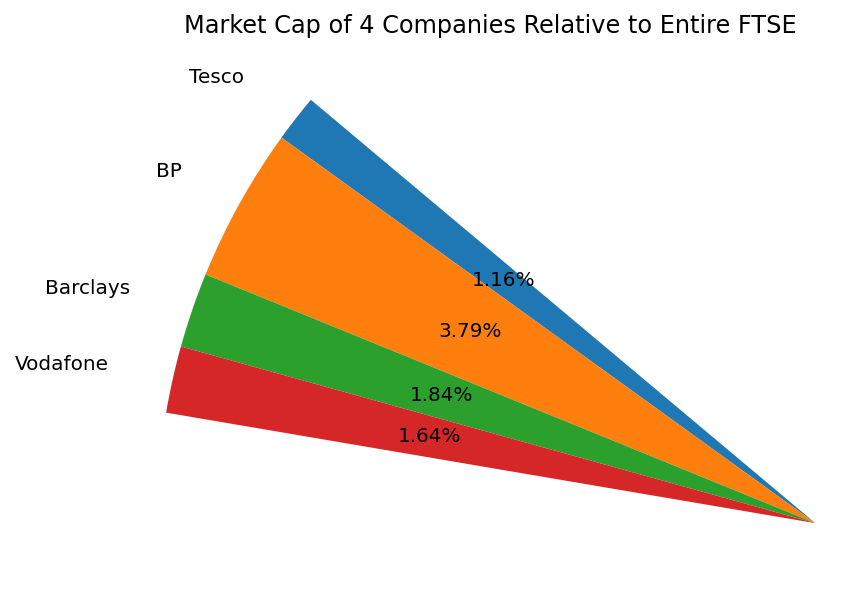

In [9]:
# 1. Market cap definitions
companies = ['Tesco', 'BP', 'Barclays', 'Vodafone']
cap = np.array([20979, 68785, 33367, 29741])
ftse = 1814000

# Normalise cap against FTSE total
norm_cap = cap / ftse


# 2. Individual companies share among themselves
def plot_market_cap_pie(cap, labels=companies):
  """Creates a pie chart showing the relative share among the 4 major companies."""
  plt.figure(dpi=144)
  plt.pie(cap, labels=labels, autopct='%1.1f%%', startangle=140)
  plt.title('Market Cap Share Among the 4 Companies')
  plt.axis('equal')
  plt.show()


plot_market_cap_pie(cap)


# 3. Share of each company relative to the entire FTSE (unnormalised / partial pie)
def plot_market_cap_pie_unnormalised(norm_cap, labels=companies):
  """Creates an unnormalised pie chart showing the 4 companies' share

  as part of the total FTSE index (normalize=False leaves the remaining circle
  open).
  """
  plt.figure(dpi=144)
  plt.pie(
      norm_cap,
      labels=labels,
      autopct='%1.2f%%',
      normalize=False,
      startangle=140,
  )
  plt.title('Market Cap of 4 Companies Relative to Entire FTSE')
  plt.axis('equal')
  plt.show()


plot_market_cap_pie_unnormalised(norm_cap)